1.2 工具调用的方式
在LangChain中，工具（Tools）实际上是指明确定义了输入和输出的
可调用函数。因此，
工具调用
(Tool Calling) 也被称为
函数调用(Function Calling) 。
具体有两种调用方式：
方式1：直接调用
这种方式，适合测试时使用。

In [1]:
from langchain_core.tools import tool


@tool
def get_weather(city: str) -> str:
    """
    获取指定城市的天气信息
    参数:
    city: 城市名称，如"北京"、"上海"
    返回:
    天气信息字符串
    """
    # 你的实现
    return city + "晴天，温度 15°C"


# 使用 .invoke() 方法
result = get_weather.invoke({"city": "北京"})
print(result)

北京晴天，温度 15°C


方式2：绑定到模型（主流）
这种方式，让AI来调用，开发中使用。

In [2]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os

# 从.env文件中加载环境变量
load_dotenv(override=True)
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
model = init_chat_model(model="deepseek-v4-flash",
                        model_provider="deepseek",
                        api_key=DEEPSEEK_API_KEY,
                        base_url='https://api.deepseek.com')

from langchain_core.tools import tool


# 定义工具
@tool
def get_weather(city: str) -> str:
    """获取指定城市的天气"""
    # 你的实现
    return "晴天，温度 15°C"


# 绑定工具
model_with_tools = model.bind_tools([get_weather])
# AI 可以决定是否调用工具
response = model_with_tools.invoke("北京天气如何？")
# response = model_with_tools.invoke("2 + 3 = ？")
# 检查 AI 是否要调用工具
if response.tool_calls:
    print("AI 想调用工具：", response.tool_calls)
else:
    print("AI 直接回答：", response.content)

AI 想调用工具： [{'name': 'get_weather', 'args': {'city': '北京'}, 'id': 'call_00_CGhnbswhjv9EBnmtdzbr7203', 'type': 'tool_call'}]


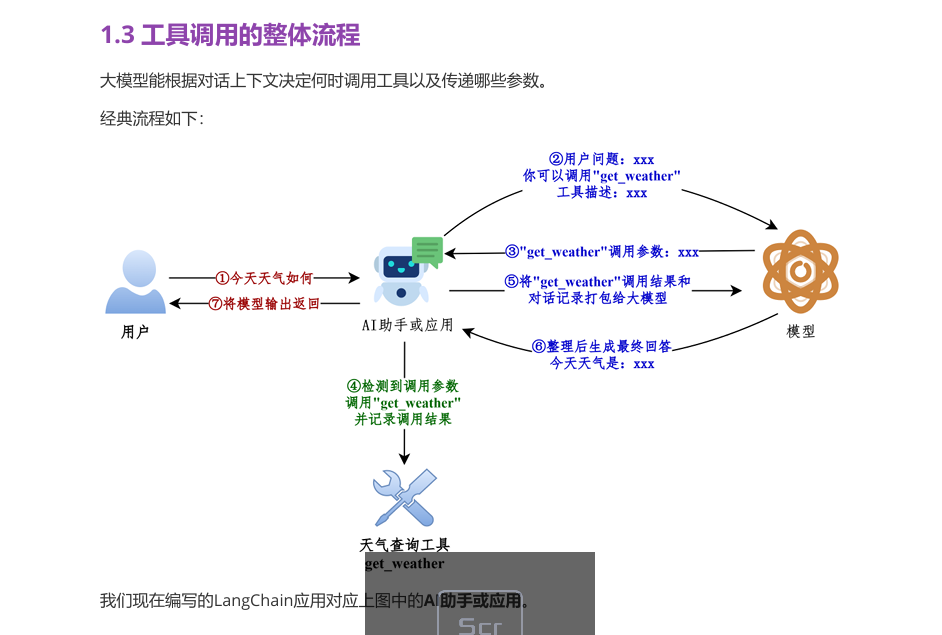

参考2：使用@tool修饰

In [3]:
from langchain.messages import HumanMessage, ToolMessage


#定义工具
@tool
def get_weather(city: str):
    """获取天气的工具"""
    return f"{city}天气晴朗~"


# 将模型和工具绑定
model_with_tools = model.bind_tools([get_weather])

#创建消息列表
messages = [
    HumanMessage("今天北京天气如何")
]
# 模型生成调用工具请求
response = model_with_tools.invoke(messages)

# 添加AIMessage
messages.append(response)

# 解析工具调用
# 从响应中提取工具调用
tool_calls = response.tool_calls
for tool_call in tool_calls:
    # 检查工具调用是否是get_weather
    if tool_call["name"] == "get_weather":
        # 调用工具get_weather
        tool_response = get_weather.invoke(tool_call)
        print(type(tool_response))
        # 添加工具响应到消息列表
        messages.append(tool_response)
print("=====================> messages <=====================")
for msg in messages:
    msg.pretty_print()
print("=====================> messages <=====================")
final_response = model_with_tools.invoke(messages)
print(f"final_response: \n{final_response}")

<class 'langchain_core.messages.tool.ToolMessage'>
=====================> messages <=====================
================================ Human Message =================================

今天北京天气如何
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_00_xyv3XE8jA2s2Zv32bpQm7274)
 Call ID: call_00_xyv3XE8jA2s2Zv32bpQm7274
  Args:
    city: 北京
================================= Tool Message =================================
Name: get_weather

北京天气晴朗~
=====================> messages <=====================
final_response: 
content='今天北京天气 **晴朗** ☀️，是个好天气！适合出门活动或者晒晒太阳。不过建议您出门前还是留意一下具体的温度和空气质量哦～' additional_kwargs={'refusal': None, 'reasoning_content': '工具返回了"北京天气晴朗~"，说明今天北京的天气是晴朗的。'} response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 356, 'total_tokens': 408, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 17, 'rejected_prediction_tokens': None}, 'p